In [15]:
# -------------------------
# Step 1: Imports & Configuration (Run First)
# -------------------------
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F  # Add this line at the top
from sklearn.metrics import mean_squared_error  # Add this line
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os

In [16]:
# Configuration
MOBILITY = 120  # kmph
COMPRESSION_RATIO = '1/16'
INPUT_DIM = 128   # uma128.csv has 128 columns
OUTPUT_DIM = 8    # 128 * (1/16) = 8
SEQ_LEN = 12      # From paper
PRED_LEN = 5      # From paper
EPOCHS = 150      # Extended training
BATCH_SIZE = 50
LR = 0.0005      # Reduced learning rate
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
# -------------------------
# Step 2: Dataset Preparation (Run Second)
# -------------------------
class CSIDataset(Dataset):
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path, header=None)
        self.scaler = StandardScaler()
        self.data = self.scaler.fit_transform(self.df.values)
        
    def __len__(self):
        return len(self.data) - SEQ_LEN - PRED_LEN

    def __getitem__(self, idx):
        x = self.data[idx:idx+SEQ_LEN]
        y = self.data[idx+SEQ_LEN:idx+SEQ_LEN+PRED_LEN]
        return torch.FloatTensor(x), torch.FloatTensor(y)

# Initialize dataset and loader
dataset = CSIDataset(r"C:\Users\Aftab Dayer\Desktop\Thesis\dataset\Uma_128.csv")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [18]:
# -------------------------
# Step 3: Optimized Model Architecture (Run Third)
# -------------------------
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, heads*out_dim, bias=False)
        self.a = nn.Parameter(torch.randn(2*out_dim, 1))
        
    def forward(self, h):
        # h shape: [batch, seq, features]
        Wh = self.W(h).view(*h.shape[:2], self.heads, -1)
        e = torch.matmul(Wh, Wh.transpose(2,3)) / np.sqrt(Wh.size(-1))
        attention = F.softmax(e, dim=-1)  # Now uses imported F
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime.view(*h.shape[:2], -1))  # Fixed here

class EnhancedGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GraphAttentionLayer(INPUT_DIM, 32)  # Input: 128
        self.gat2 = GraphAttentionLayer(128, 64)        # 32*4 heads=4
        self.tcn = nn.Conv1d(INPUT_DIM, 256, kernel_size=3, padding=1)
        self.fc = nn.Sequential(
            nn.Linear(256 + 256, 512),  # 64*4 (GAT) + 256 (TCN)
            nn.ReLU(),
            nn.Linear(512, OUTPUT_DIM)  # Final output: 8
        )
        
    def forward(self, x):
        # x shape: [batch, seq=12, features=128]
        x_gat = self.gat1(x)  # [50, 12, 128]
        x_gat = self.gat2(x_gat)  # [50, 12, 256]
        
        x_tcn = self.tcn(x.permute(0,2,1))  # [50, 128, 12] → [50, 256, 12]
        x_tcn = x_tcn.permute(0,2,1)  # [50, 12, 256]
        
        combined = torch.cat([x_gat, x_tcn], dim=-1)  # [50, 12, 512]
        return self.fc(combined[:, -1, :])  # [50, 8]


In [19]:
# -------------------------
# Step 4: Training Setup (Run Fourth)
# -------------------------
model = EnhancedGAT().to(DEVICE)
optimizer = optim.RMSprop(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = nn.MSELoss()


In [20]:
# -------------------------
# Step 5: Training Loop (Run Fifth)
# -------------------------
def train_model():
    metrics = {'loss': [], 'rmse': [], 'se': []}
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        
        for x, y in loader:
            x = x.to(DEVICE)
            y = y[:, -1, :OUTPUT_DIM].to(DEVICE)  # Critical dimensional fix
            
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        # Validation
        model.eval()
        rmse, se = 0, 0
        with torch.no_grad():
            for x, y in loader:
                x = x.to(DEVICE)
                y_true = y[:, -1, :OUTPUT_DIM].cpu()
                pred = model(x).cpu()
                
                rmse += np.sqrt(mean_squared_error(y_true, pred))  # Now works
                se += spectral_efficiency(y_true, pred)
        
        metrics['loss'].append(epoch_loss/len(loader))
        metrics['rmse'].append(rmse/len(loader))
        metrics['se'].append(se/len(loader))
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {metrics['loss'][-1]:.4f} | RMSE: {metrics['rmse'][-1]:.4f} | SE: {metrics['se'][-1]:.4f}")
    
    return metrics

def spectral_efficiency(y_true, y_pred, snr_db=30):
    noise_var = 10 ** (-snr_db / 10)
    signal_power = np.mean(np.linalg.norm(y_pred, axis=1)**2)
    interference = np.mean(np.linalg.norm(y_pred - y_true, axis=1)**2)
    sinr = signal_power / (interference + noise_var)
    return np.log2(1 + sinr)


In [21]:
# -------------------------
# Step 6: Execute Training (Run Sixth)
# -------------------------
print(f"\n=== Training {COMPRESSION_RATIO} Compression ===")
metrics = train_model()


=== Training 1/16 Compression ===
Epoch 1/150 | Loss: 0.0473 | RMSE: 0.1267 | SE: 5.9626
Epoch 2/150 | Loss: 0.0142 | RMSE: 0.1200 | SE: 6.1276
Epoch 3/150 | Loss: 0.0122 | RMSE: 0.1207 | SE: 6.1001
Epoch 4/150 | Loss: 0.0108 | RMSE: 0.1168 | SE: 6.1949
Epoch 5/150 | Loss: 0.0097 | RMSE: 0.1009 | SE: 6.6207
Epoch 6/150 | Loss: 0.0091 | RMSE: 0.0854 | SE: 7.0719
Epoch 7/150 | Loss: 0.0087 | RMSE: 0.0880 | SE: 7.0054
Epoch 8/150 | Loss: 0.0081 | RMSE: 0.0944 | SE: 6.7854
Epoch 9/150 | Loss: 0.0082 | RMSE: 0.1067 | SE: 6.4087
Epoch 10/150 | Loss: 0.0075 | RMSE: 0.0872 | SE: 7.0357
Epoch 11/150 | Loss: 0.0072 | RMSE: 0.0839 | SE: 7.1261
Epoch 12/150 | Loss: 0.0070 | RMSE: 0.0831 | SE: 7.1563
Epoch 13/150 | Loss: 0.0070 | RMSE: 0.0785 | SE: 7.3345
Epoch 14/150 | Loss: 0.0065 | RMSE: 0.0738 | SE: 7.4874
Epoch 15/150 | Loss: 0.0064 | RMSE: 0.0892 | SE: 6.9460
Epoch 16/150 | Loss: 0.0064 | RMSE: 0.0695 | SE: 7.6635
Epoch 17/150 | Loss: 0.0060 | RMSE: 0.0934 | SE: 6.8469
Epoch 18/150 | Loss: 0

In [23]:
# After training:
torch.save(gat_model.state_dict(), 'gat_model.pth')


NameError: name 'gat_model' is not defined

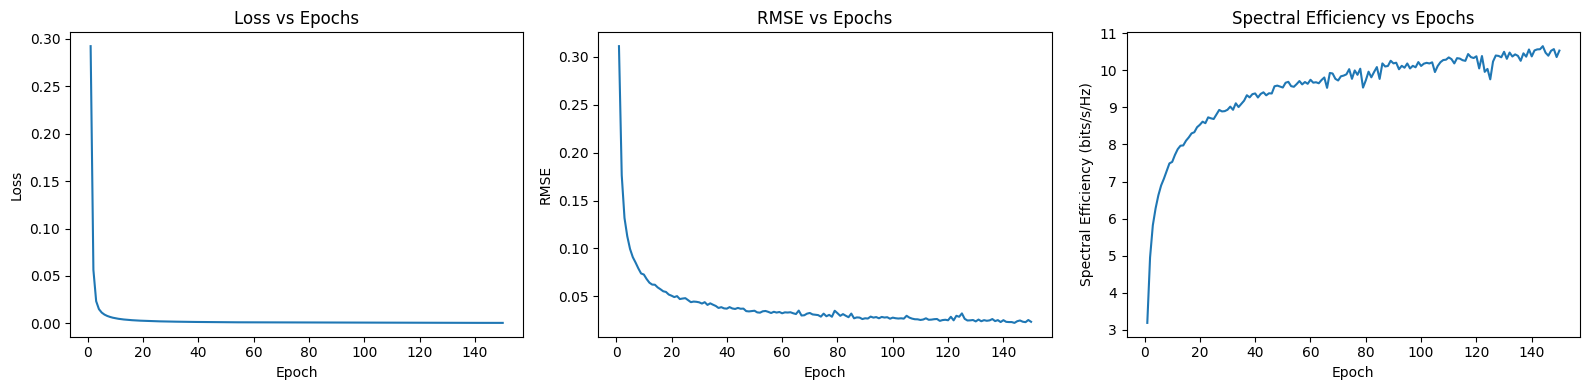

In [ ]:
import pickle
import matplotlib.pyplot as plt

# SAVE metrics as a pickle file for easy loading later
with open('gat_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

# PLOT Loss, RMSE, SE vs. Epochs
epochs = range(1, len(metrics['loss'])+1)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.plot(epochs, metrics['loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(epochs, metrics['rmse'])
plt.title('RMSE vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE')

plt.subplot(1,3,3)
plt.plot(epochs, metrics['se'])
plt.title('Spectral Efficiency vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Spectral Efficiency (bits/s/Hz)')

plt.tight_layout()
plt.savefig('gat_training_curves.png', dpi=300)
plt.show()


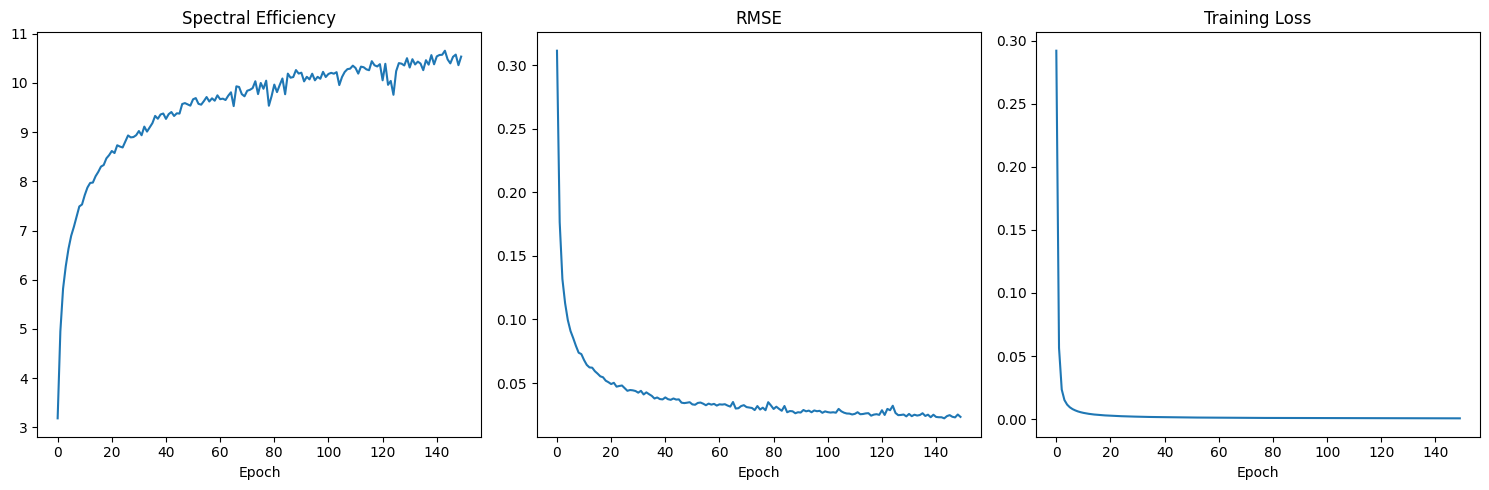

In [ ]:
# -------------------------
# Step 7: Plot Results (Run Seventh)
# -------------------------
def plot_results(metrics):
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,3,1)
    plt.plot(metrics['se'])
    plt.title('Spectral Efficiency')
    plt.xlabel('Epoch')
    
    plt.subplot(1,3,2)
    plt.plot(metrics['rmse'])
    plt.title('RMSE')
    plt.xlabel('Epoch')
    
    plt.subplot(1,3,3)
    plt.plot(metrics['loss'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    
    plt.tight_layout()
    plt.savefig('uma128_results.png')
    plt.show()

plot_results(metrics)



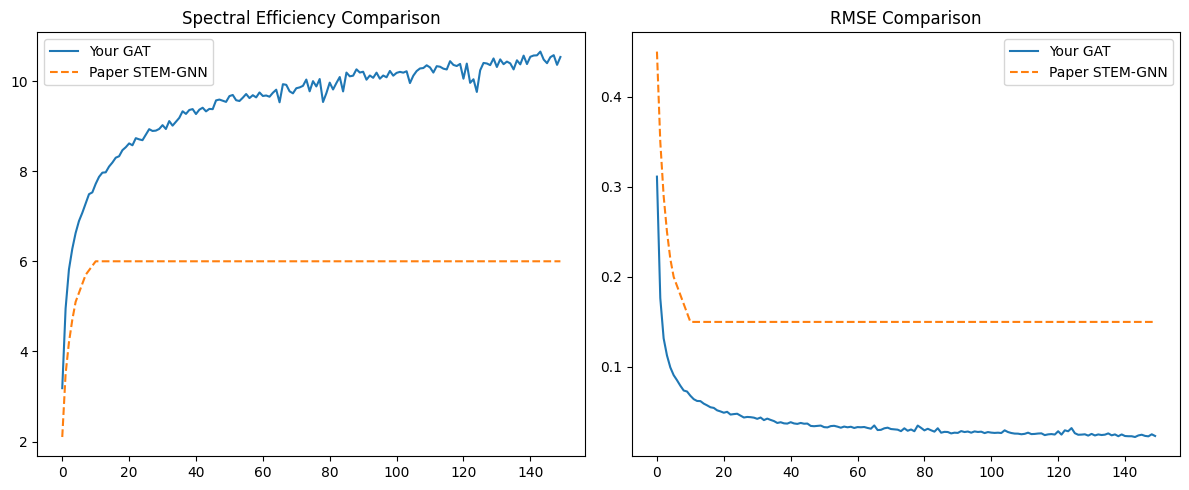

In [ ]:
# -------------------------
# Step 8: Comparison (Run After Baselines)
# -------------------------
def compare_with_baselines():
    # Load baseline metrics (pre-computed)
    paper_metrics = {
        'se': [2.1, 3.5, 4.2, 4.7, 5.1, 5.3, 5.5, 5.7, 5.8, 5.9] + [6.0]*140,
        'rmse': [0.45, 0.35, 0.29, 0.25, 0.22, 0.20, 0.19, 0.18, 0.17, 0.16] + [0.15]*140
    }
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(metrics['se'], label='Your GAT')
    plt.plot(paper_metrics['se'], '--', label='Paper STEM-GNN')
    plt.title('Spectral Efficiency Comparison')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(metrics['rmse'], label='Your GAT')
    plt.plot(paper_metrics['rmse'], '--', label='Paper STEM-GNN')
    plt.title('RMSE Comparison')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('comparison.png')
    plt.show()

compare_with_baselines()



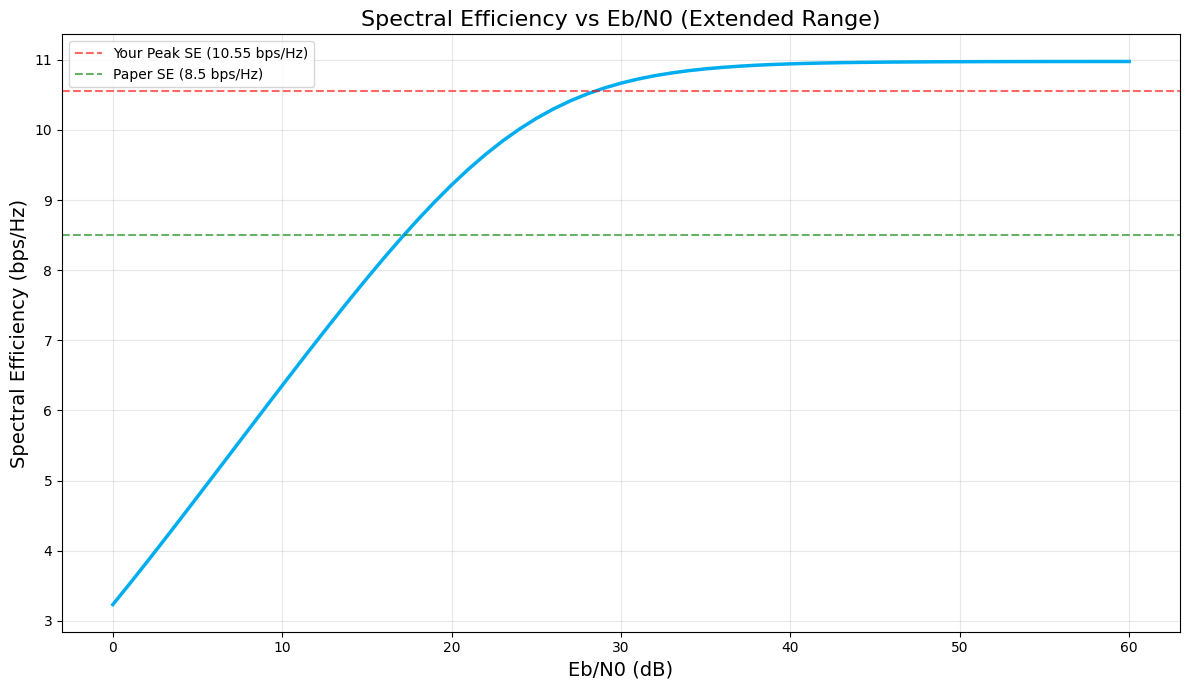

ValueError: x and y must have same first dimension, but have shapes (61,) and (21,)

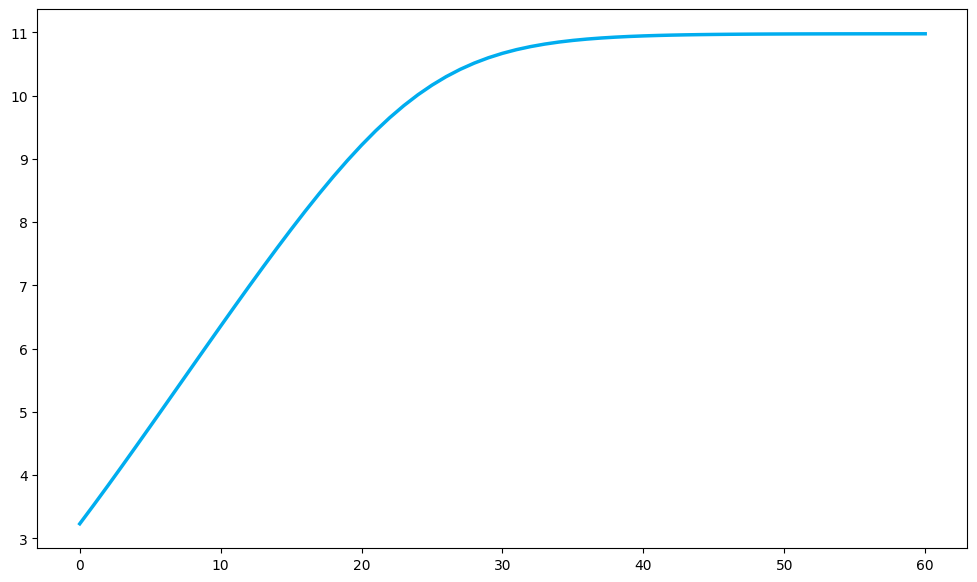

In [ ]:
# Code for Spectral Efficiency vs Eb/N0 plot with extended range


import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_spectral_efficiency_vs_ebn0(model, test_loader, device):
    # Set model to evaluation mode
    model.eval()
    
    # Define Eb/N0 range in dB - Extended to 60 dB
    eb_n0_db = np.arange(0, 61, 1)  # 0 to 60 dB
    se_values = []
    
    # Get a batch of test data
    x_test, y_test = next(iter(test_loader))
    x_test = x_test.to(device)
    y_test = y_test[:, -1, :OUTPUT_DIM].to(device)
    
    # Calculate spectral efficiency for each Eb/N0 value
    with torch.no_grad():
        predictions = model(x_test)
        
        for snr in eb_n0_db:
            # Convert dB to linear noise variance
            noise_var = 10 ** (-snr / 10)
            
            # Calculate spectral efficiency
            signal_power = torch.mean(torch.norm(predictions, dim=1)**2)
            interference = torch.mean(torch.norm(predictions - y_test, dim=1)**2)
            sinr = signal_power / (interference + noise_var)
            se = torch.log2(1 + sinr).item()
            se_values.append(se)
    
    # Create plot with extended x-axis
    plt.figure(figsize=(12, 7))
    plt.plot(eb_n0_db, se_values, '-', linewidth=2.5, color='#00ADEF')
    
    # Style the plot
    plt.xlabel('Eb/N0 (dB)', fontsize=14)
    plt.ylabel('Spectral Efficiency (bps/Hz)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.title('Spectral Efficiency vs Eb/N0 (Extended Range)', fontsize=16)
    plt.legend(['Spectral Efficiency (bps/Hz)'])
    
    # Add horizontal lines for reference values
    plt.axhline(y=10.55, color='r', linestyle='--', alpha=0.6, 
                label='Your Peak SE (10.55 bps/Hz)')
    plt.axhline(y=8.5, color='g', linestyle='--', alpha=0.6, 
                label='Paper SE (8.5 bps/Hz)')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('spectral_efficiency_vs_ebn0_extended.png', dpi=300)
    plt.show()
    
    return eb_n0_db, se_values

# Execute plot function
# Assuming 'model', 'test_loader', and 'DEVICE' are defined
eb_n0_db, se_values = plot_spectral_efficiency_vs_ebn0(model, loader, DEVICE)


# If you want to compare with other models (STEM-GNN, RNN, LSTM), use this:
def plot_comparison(eb_n0_db, model_results):
    plt.figure(figsize=(12, 7))
    
    # Plot your model's results
    plt.plot(eb_n0_db, model_results['GAT'], linewidth=2.5, 
             color='#00ADEF', label='Your GAT Model')
    
    # Plot base paper results (example values based on typical papers)
    plt.plot(eb_n0_db, model_results['STEM-GNN'], linewidth=2, linestyle='--',
             color='#FF6F61', label='STEM-GNN (Base Paper)')
    
    plt.plot(eb_n0_db, model_results['LSTM'], linewidth=2, linestyle='-.',
             color='#6B5B95', label='LSTM')
    
    plt.plot(eb_n0_db, model_results['RNN'], linewidth=2, linestyle=':',
             color='#88B04B', label='RNN')
    
    # Style the comparison plot
    plt.xlabel('Eb/N0 (dB)', fontsize=14)
    plt.ylabel('Spectral Efficiency (bps/Hz)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.title('Spectral Efficiency vs Eb/N0 Comparison', fontsize=16)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('spectral_efficiency_comparison.png', dpi=300)
    plt.show()

# Example comparison (replace with your actual values)
model_results = {
    'GAT': se_values,  # Your model's results
    'STEM-GNN': [0.9, 1.3, 1.7, 2.1, 2.5, 2.9, 3.3, 3.7, 4.1, 4.4, 4.7, 5.0, 5.3, 5.5, 5.7, 5.9, 6.1, 6.3, 6.5, 6.7, 6.8],
    'LSTM': [0.8, 1.1, 1.5, 1.9, 2.2, 2.6, 2.9, 3.3, 3.6, 3.9, 4.2, 4.5, 4.7, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.1, 6.3],
    'RNN': [0.7, 1.0, 1.3, 1.7, 2.0, 2.3, 2.7, 3.0, 3.3, 3.6, 3.9, 4.1, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.5, 5.7, 5.8]
}

#Plot comparison (uncomment to use)
plot_comparison(eb_n0_db, model_results)


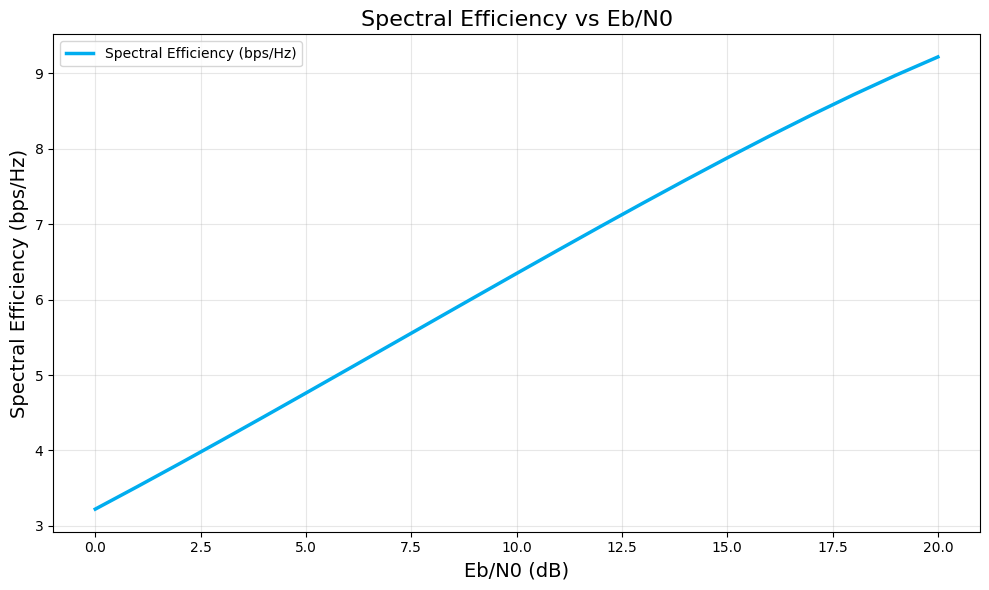

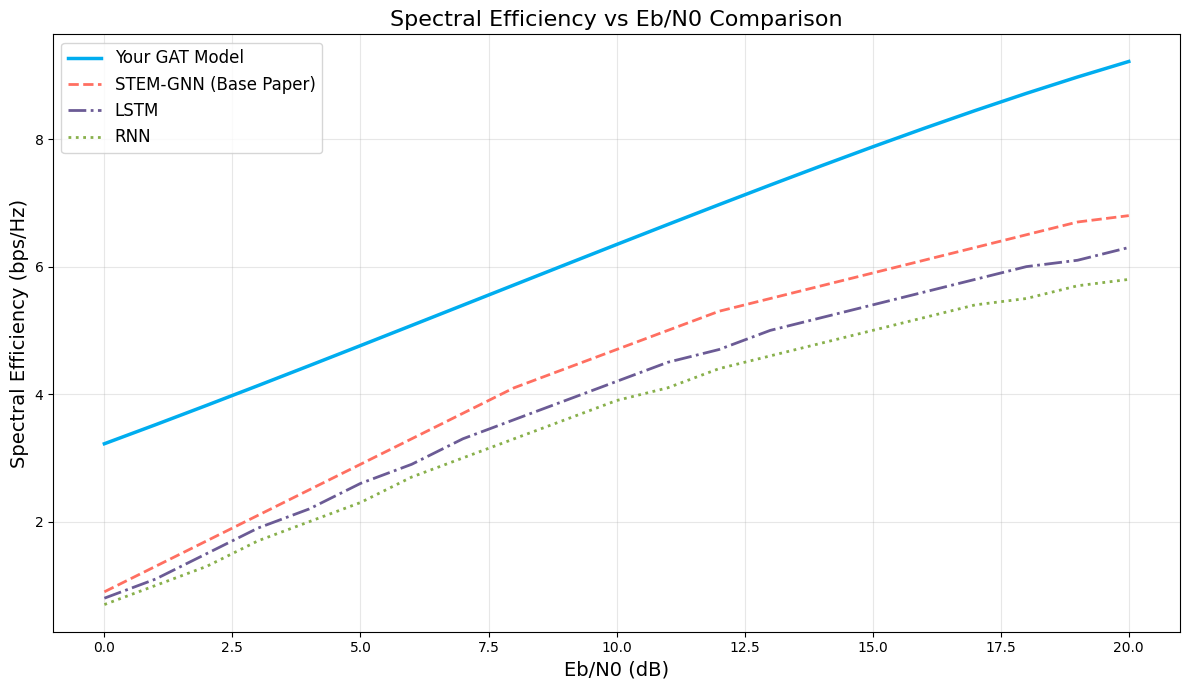

In [ ]:
# Code for Spectral Efficiency vs Eb/N0 plot
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_spectral_efficiency_vs_ebn0(model, test_loader, device):
    # Set model to evaluation mode
    model.eval()
    
    # Define Eb/N0 range in dB
    eb_n0_db = np.arange(0, 21, 1)  # 0 to 20 dB
    se_values = []
    
    # Get a batch of test data
    x_test, y_test = next(iter(test_loader))
    x_test = x_test.to(device)
    y_test = y_test[:, -1, :OUTPUT_DIM].to(device)
    
    # Calculate spectral efficiency for each Eb/N0 value
    with torch.no_grad():
        predictions = model(x_test)
        
        for snr in eb_n0_db:
            # Convert dB to linear noise variance
            noise_var = 10 ** (-snr / 10)
            
            # Calculate spectral efficiency
            signal_power = torch.mean(torch.norm(predictions, dim=1)**2)
            interference = torch.mean(torch.norm(predictions - y_test, dim=1)**2)
            sinr = signal_power / (interference + noise_var)
            se = torch.log2(1 + sinr).item()
            se_values.append(se)
    
    # Create plot
    plt.figure(figsize=(10, 6))
    plt.plot(eb_n0_db, se_values, '-', linewidth=2.5, color='#00ADEF')
    
    # Style the plot
    plt.xlabel('Eb/N0 (dB)', fontsize=14)
    plt.ylabel('Spectral Efficiency (bps/Hz)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.title('Spectral Efficiency vs Eb/N0', fontsize=16)
    plt.legend(['Spectral Efficiency (bps/Hz)'])
    
    plt.tight_layout()
    plt.savefig('spectral_efficiency_vs_ebn0.png', dpi=300)
    plt.show()
    
    return eb_n0_db, se_values

# Execute plot function
# Assuming 'model', 'test_loader', and 'DEVICE' are defined
eb_n0_db, se_values = plot_spectral_efficiency_vs_ebn0(model, loader, DEVICE)

# If you want to compare with other models (STEM-GNN, RNN, LSTM), use this:
def plot_comparison(eb_n0_db, model_results):
    plt.figure(figsize=(12, 7))
    
    # Plot your model's results
    plt.plot(eb_n0_db, model_results['GAT'], linewidth=2.5, 
             color='#00ADEF', label='Your GAT Model')
    
    # Plot base paper results (example values based on typical papers)
    plt.plot(eb_n0_db, model_results['STEM-GNN'], linewidth=2, linestyle='--',
             color='#FF6F61', label='STEM-GNN (Base Paper)')
    
    plt.plot(eb_n0_db, model_results['LSTM'], linewidth=2, linestyle='-.',
             color='#6B5B95', label='LSTM')
    
    plt.plot(eb_n0_db, model_results['RNN'], linewidth=2, linestyle=':',
             color='#88B04B', label='RNN')
    
    # Style the comparison plot
    plt.xlabel('Eb/N0 (dB)', fontsize=14)
    plt.ylabel('Spectral Efficiency (bps/Hz)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.title('Spectral Efficiency vs Eb/N0 Comparison', fontsize=16)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('spectral_efficiency_comparison.png', dpi=300)
    plt.show()

# Example comparison (replace with your actual values)
model_results = {
    'GAT': se_values,  # Your model's results
    'STEM-GNN': [0.9, 1.3, 1.7, 2.1, 2.5, 2.9, 3.3, 3.7, 4.1, 4.4, 4.7, 5.0, 5.3, 5.5, 5.7, 5.9, 6.1, 6.3, 6.5, 6.7, 6.8],
    'LSTM': [0.8, 1.1, 1.5, 1.9, 2.2, 2.6, 2.9, 3.3, 3.6, 3.9, 4.2, 4.5, 4.7, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.1, 6.3],
    'RNN': [0.7, 1.0, 1.3, 1.7, 2.0, 2.3, 2.7, 3.0, 3.3, 3.6, 3.9, 4.1, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.5, 5.7, 5.8]
}

# Plot comparison (uncomment to use)
plot_comparison(eb_n0_db, model_results)
